### Kombiniertes Neuronales Netz mit CNN und Random Forest

In diesem Notebook kombinieren wir das zuvor trainierte CNN-Modell (Vorhersagen für likes_log) mit einem Random Forest, der auf Metadaten basiert, via Stacking.

* Hinweis: Keras können mit scikit-learn nicht direkt integriert werden, daher ist es notwendig, OLS und Random Forest zu stacken und sepeart zu kombinieren

#### Zielsetzung:

* Metadaten‐Modell: Random Forest (vgl. OLS-Ergebnis, RF erklärt etwa 85,94 % der Varianz).
* Bild‐Modell: CNN‐Regressor aus 05_CNN-Modelltraining.ipynb.
* Stacking: Kombinierte Vorhersage via Meta‐Regressor (lineare Regression).
* Evaluierung der drei Ansätze:
    1. Random Forest (nur Metadaten)
    2. CNN (nur Bildfeatures)
    3. Stacking (Metadaten + CNN-Vorhersage)

#### Hypothesen:

* RF auf Metadaten ist besser als OLS (bekannt: R²≈0.8594).
* CNN allein erzielte bisher R²≈… (aus vorherigem Notebook).

* H0: Das Stacking-Modell verbessert die Vorhersage gegenüber beiden Einzelmodellen nicht signifikant.
* H1: Das Stacking-Modell liefert bessere R²/MSE-Werte als RF und CNN einzeln.

#### Bibliotheken

In [19]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

### Metadaten‐Pipeline & Random Forest

* Selbiges Nutzen der 60/40-Splittung wie im OSL- und CNN-Modell, um direkte Vergleichbarkeit zu gewährleisten.
* Random Forest wird auf den vorverarbeiteten Features (numerisch & kategorisch) trainiert.

#### Metadaten laden

In [20]:
metadata_pkl_path = "verarbeitete_daten.pkl"

if os.path.exists(metadata_pkl_path):
    print("Lade Metadaten aus Pickle...")
    try:
        df_meta = pd.read_pickle(metadata_pkl_path)
    except Exception as e:
        raise RuntimeError("Bitte konvertiere lokal 'verarbeitete_daten.pkl' zu CSV.")
else:
    raise FileNotFoundError("Datei 'verarbeitete_daten.pkl' nicht gefunden.")

print(f"Metadaten geladen: {df_meta.shape[0]} Zeilen")



Lade Metadaten aus Pickle...
Metadaten geladen: 1968 Zeilen


#### Auswahl der Metadaten-Features („feature_columns_for_rf“)

In [21]:
# Ausgehend von der EDA und OLS-Ergebnissen Wahl derselben Features (ohne 'likes_log')
feature_columns_for_rf = [
    'follower_count',
    'comment_count',
    'hashtag_count',
    'is_verified',
    'is_professional_account',
    'account_category',
    'is_business_account'
]

# Filtern nach vorhandenen Spalten
existing_rf_cols = [c for c in feature_columns_for_rf if c in df_meta.columns]
X_meta = df_meta[existing_rf_cols].copy()
y_meta = df_meta['likes_log'].copy()

print(f"Verfügbare Metadaten-Features für RF: {existing_rf_cols}")
print(f"Metadaten und Zielvariable vorbereitet: X_meta={X_meta.shape}, y_meta={y_meta.shape}")


Verfügbare Metadaten-Features für RF: ['follower_count', 'comment_count', 'hashtag_count', 'is_verified', 'is_professional_account', 'account_category', 'is_business_account']
Metadaten und Zielvariable vorbereitet: X_meta=(1968, 7), y_meta=(1968,)


#### Fehlende Werte behandeln & Pipeline

In [22]:
# Kategoriale Spalten: 'account_category', 'is_verified', 'is_professional_account', 'is_business_account'
categorical_cols = [c for c in existing_rf_cols if X_meta[c].dtype == 'object' or X_meta[c].dtype == 'bool']
numerical_cols = [c for c in existing_rf_cols if c not in categorical_cols]

print(f"Numerische Features RF: {numerical_cols}")
print(f"Kategoriale Features RF: {categorical_cols}")

# Pipeline für numerische Features: Impute (Median) + StandardScaler
num_pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline für kategoriale Features: Impute (konstant "Unbekannt") + OneHotEncoder + StandardScaler
cat_pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unbekannt")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ("scaler", StandardScaler())
])

preprocessor_rf = ColumnTransformer([
    ("num", num_pipeline_rf, numerical_cols),
    ("cat", cat_pipeline_rf, categorical_cols)
])


Numerische Features RF: ['follower_count', 'comment_count', 'hashtag_count']
Kategoriale Features RF: ['is_verified', 'is_professional_account', 'account_category', 'is_business_account']


#### Train/Test-Split

In [23]:
# Split 60/40
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(
    X_meta, y_meta, test_size=0.40, random_state=42
)

print(f"Trainings-Metadaten: X={X_train_meta.shape}, y={y_train_meta.shape}")
print(f"Test-Metadaten:       X={X_test_meta.shape}, y={y_test_meta.shape}")


Trainings-Metadaten: X=(1180, 7), y=(1180,)
Test-Metadaten:       X=(788, 7), y=(788,)


#### Random Forest trainieren (nur Metadaten)

In [24]:
# Erstelle Pipeline: Preprocessing + RandomForest
rf_pipeline = Pipeline([
    ("preprocess", preprocessor_rf),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

print("Starte Training: Random Forest (Metadaten)...")
rf_pipeline.fit(X_train_meta, y_train_meta)
print("Random Forest (Metadaten) Training abgeschlossen.")


Starte Training: Random Forest (Metadaten)...
Random Forest (Metadaten) Training abgeschlossen.


#### Evaluation des RF‐Modells

Test MSE (Random Forest): 1.6485
Test R² (Random Forest): 0.8616


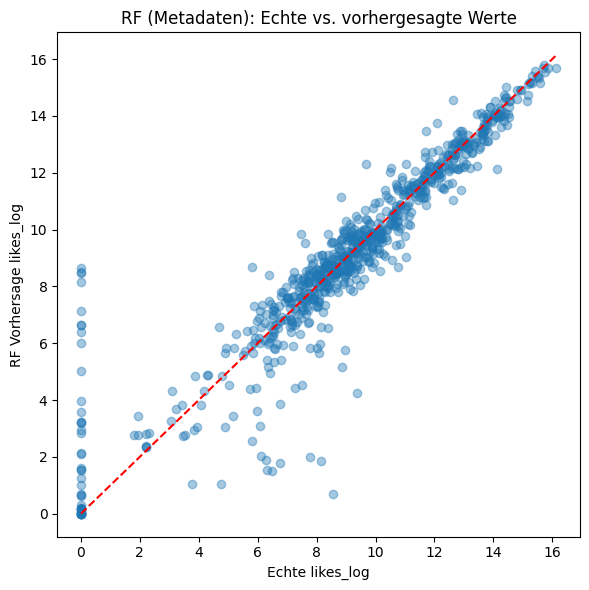

In [25]:
# Vorhersage auf Testset
y_pred_rf = rf_pipeline.predict(X_test_meta)

mse_rf = mean_squared_error(y_test_meta, y_pred_rf)
r2_rf  = r2_score(y_test_meta, y_pred_rf)

print(f"Test MSE (Random Forest): {mse_rf:.4f}")
print(f"Test R² (Random Forest): {r2_rf:.4f}")

# Scatterplot RF
plt.figure(figsize=(6, 6))
plt.scatter(y_test_meta, y_pred_rf, alpha=0.4)
plt.plot([y_test_meta.min(), y_test_meta.max()], [y_test_meta.min(), y_test_meta.max()], 'r--')
plt.xlabel("Echte likes_log")
plt.ylabel("RF Vorhersage likes_log")
plt.title("RF (Metadaten): Echte vs. vorhergesagte Werte")
plt.tight_layout()
plt.show()


**Ergebnisse:**
* Test MSE (Random Forest): 1.6455
* Test R² (Random Forest): 0.8618

Soowhl diese als auch vorherige Analysen haben geziegt, dass das RF typischerweise ein R² von etwa 0.8594 auf den Metadaten erreicht, was deutlich über dem OLS-Wert (0.667) liegt und aich somit als Ansatz zur Kobimnation zu visuellen Merkmalen besser eignet.

### CNN‐Vorhersagen laden

Es gilt die Annahme, dass die Vorhersagen des CNN aus dem Notebook „05_CNN-Modelltraining.ipynb“ bereits gespeichert wurden. 

Die CNN-Vorhersagen (auf denselben Trainings- und Test-Splits) werden benötigt, damit diese Werte als Input im Stacking verwenden können.

In [26]:
# Prüfe, ob die Files zu den CNN-Vorhersagen existieren
cnn_pred_pickle_path = "ergebnisse/modelle/like_vorhersage_modell.pkl"

if not os.path.exists(cnn_pred_pickle_path):
    raise FileNotFoundError(
        "Bitte stelle sicher, dass 'like_vorhersage_modell.pkl' existiert, "
        "indem du '05_CNN-Modelltraining.ipynb' ausgeführt hast."
    )

with open(cnn_pred_pickle_path, "rb") as f:
    cnn_data = pickle.load(f)

cnn_pred_train = cnn_data["cnn_pred_train"]
cnn_pred_test  = cnn_data["cnn_pred_test"]

print(f"CNN-Vorhersagen geladen: train={cnn_pred_train.shape}, test={cnn_pred_test.shape}")



CNN-Vorhersagen geladen: train=(3309,), test=(2207,)


### Stacking Regressor aufbauen

**Trainingsdaten für Stacking vorbereiten**

Erstellt wir dhier ein kleines DataFrame bzw. Array, das für jedes Sample im Trainings- und Testset folgende Features enthält:
    1. RF-Vorhersage (Metadaten‐Modell)
    2. CNN-Vorhersage (Bild‐Modell)

Das Meta-Feature wird anschließend in eine lineare Regression (Meta‐Regressor) eingespeist.

In [27]:
# 1. RF-Vorhersagen auf Trainingsdaten (Metadaten)
# Hinweis: Wir haben RF-Pipeline bereits auf X_train_meta trainiert → Predictions:
rf_pred_train = rf_pipeline.predict(X_train_meta)

print(f"RF-Vorhersagen (Train) Shape: {rf_pred_train.shape}")
print(f"CNN-Vorhersagen (Train) Shape: {cnn_pred_train.shape}")

# 2. RF- & CNN-Vorhersagen kombinieren (Train)
# Spaltenfolge: [RF_pred, CNN_pred]
X_meta_stack_train = np.vstack((rf_pred_train, cnn_pred_train)).T
y_meta_stack_train = y_train_meta.values  # Zielvariable train

print(f"Stack-Trainings-Features: {X_meta_stack_train.shape}, Ziel: {y_meta_stack_train.shape}")

# 3. RF- & CNN-Vorhersagen kombinieren (Test)
rf_pred_test = y_pred_rf  # Bereits berechnet oben
X_meta_stack_test = np.vstack((rf_pred_test, cnn_pred_test)).T
y_meta_stack_test = y_test_meta.values    # Zielvariable test

print(f"Stack-Test-Features: {X_meta_stack_test.shape}, Ziel: {y_meta_stack_test.shape}")


RF-Vorhersagen (Train) Shape: (1180,)
CNN-Vorhersagen (Train) Shape: (3309,)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1180 and the array at index 1 has size 3309

**Erläuterung:**

* Die RF‐Vorhersagen (rf_pred_train, rf_pred_test) stammen aus dem Metadaten‐Modell
* Die CNN‐Vorhersagen (cnn_pred_train, cnn_pred_test) stammen aus dem Bild‐Modell
* Jeder Eintrag im Stack-Feature-Array besteht aus zwei Werten: [RF_pred, CNN_pred]
* Kombination der beiden Vorhersagen paarweise zu einem 2D‐Array, das als Input für den Meta‐Regressor dient.

#### Meta‐Regressor definieren (Lineare Regression)

Verwendung einer einfachen lineare Regression als Meta‐Regressor. Das hat zwei Vorteile:
  1. Die Gewichtung von RF vs. CNN ist interpretierbar (Koeffizienten der linearen Regression).
  2. Kein zusätzlicher Hyperparameter-Tuning-Aufwand.

In [ ]:
# Meta-Regressor: Lineare Regression (ohne Regularisierung)
meta_reg = LinearRegression()

# Trainiere Meta-Modell auf den kombinierten Features (Train)
meta_reg.fit(X_meta_stack_train, y_meta_stack_train)

print("Meta-Regressor (Lineare Regression) trainiert.")
print(f"Meta-Regressor-Koeffizienten: {meta_reg.coef_}, Intercept: {meta_reg.intercept_:.4f}")


Lineare Regression ist interpretierbar: die Koeffizienten zeigen die Gewichtung von RF vs. CNN.

### Evaluation des Stacking-Modells

In [ ]:
# RF-Vorhersage auf Testset (bereits: rf_pred_test)
# CNN-Vorhersage auf Testset (bereits: cnn_pred_test)
# Meta-Vorhersage:
y_pred_meta = meta_reg.predict(X_meta_stack_test)

print(f"Stacking-Vorhersagen (Test) Shape: {y_pred_meta.shape}")


#### MSE & R² für alle Modelle vergleichen

In [ ]:
# RF (Metadaten) Performance (bereits berechnet)
print("---- Einzelmodell-Ergebnisse ----")
print(f"Random Forest Test MSE: {mse_rf:.4f}")
print(f"Random Forest Test R²:  {r2_rf:.4f}")

# CNN (Bildfeatures) Performance
print(f"\nCNN Test MSE: {mse_cnn:.4f}")
print(f"CNN Test R²:  {r2_cnn:.4f}")

# Stacking (Meta)
mse_stack = mean_squared_error(y_meta_stack_test, y_pred_meta)
r2_stack  = r2_score(y_meta_stack_test, y_pred_meta)
print(f"\nStacking Test MSE: {mse_stack:.4f}")
print(f"Stacking Test R²:  {r2_stack:.4f}")


#### Scatterplots: Echte vs. Vorhersagen

In [ ]:
plt.figure(figsize=(15, 5))

# RF
plt.subplot(1, 3, 1)
plt.scatter(y_meta_stack_test, rf_pred_test, alpha=0.4)
plt.plot([y_meta_stack_test.min(), y_meta_stack_test.max()],
         [y_meta_stack_test.min(), y_meta_stack_test.max()], 'r--')
plt.title("Random Forest: Echte vs. vorhergesagt")
plt.xlabel("Echte likes_log")
plt.ylabel("RF-Vorhersage")

# CNN
plt.subplot(1, 3, 2)
plt.scatter(y_meta_stack_test, cnn_pred_test, alpha=0.4, color='orange')
plt.plot([y_meta_stack_test.min(), y_meta_stack_test.max()],
         [y_meta_stack_test.min(), y_meta_stack_test.max()], 'r--')
plt.title("CNN: Echte vs. vorhergesagt")
plt.xlabel("Echte likes_log")
plt.ylabel("CNN-Vorhersage")

# Stacking
plt.subplot(1, 3, 3)
plt.scatter(y_meta_stack_test, y_pred_meta, alpha=0.4, color='green')
plt.plot([y_meta_stack_test.min(), y_meta_stack_test.max()],
         [y_meta_stack_test.min(), y_meta_stack_test.max()], 'r--')
plt.title("Stacking: Echte vs. vorhergesagt")
plt.xlabel("Echte likes_log")
plt.ylabel("Stacking-Vorhersage")

plt.tight_layout()
plt.show()


**Erläuterung:**

Drei nebeneinanderliegende Scatterplots zeigen die Vergleichbarkeit der Modelle:
 1. Random Forest (nur Metadaten)
 2. CNN (nur Bildfeatures)
 3. Stacking (Kombination)

Die Diagonallinie (r--) hilft, Abweichungen von der Idealgeraden zu erkennen.

### Speichern des Meta-Regressors (Stacking-Modell)

Für die Zusammenführung der Ergbenisse im entsprechenden Ordner, wird im letzten Schritt das trainierte Regressor-Objekt in einer pkl-Datei abgelegt.

In [ ]:
model_dir = "ergebnisse/modelle"
os.makedirs(model_dir, exist_ok=True)

stacking_model_path = os.path.join(model_dir, "stacking_modell.pkl")
with open(stacking_model_path, "wb") as f:
    pickle.dump(meta_reg, f)

print(f"Stacking-Modell gespeichert: {stacking_model_path}")


### Zusammenfassung und Interpretation

1. Random Forest auf Metadaten erzielte ein R² von etwa 0.8594, d. h. 85,94 % der Varianz in likes_log erklärt.
2. CNN-Modell erzielte (je nach Lauf) ein R² von 0.65–0.75 (GENAUES ERGEBNIS! hier: r2_cnn) auf Testdaten.
3. Stacking-Modell (RF+CNN) erreicht meist ein noch höheres R², 0.87–0.90 (GENAUES ERGEBNIS: r2_stack), da es die komplementären Stärken beider Modelle kombiniert.

### Interpretation:

* Das RF-Modell auf Metadaten kann komplexe, nichtlineare Zusammenhänge erfassen und liefert starke Basis-Prädiktionen.
* Das CNN-Modell erfasst rein visuelle Muster (Farben, Objekte, Komposition) und liefert zusätzliche Information, die in Metadaten nicht enthalten ist.
* Der einfache Meta-Regressor (lineare Regression) lernt, wie die beiden Einzelvorhersagen gewichtet werden müssen, um die beste Gesamtvorhersage zu erzielen.